In [18]:
import json
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
from credit_risk.evaluation import tune_threshold
from credit_risk.features import FEATURES_DIR, load_features

In [20]:
cwd = Path.cwd()
project_root = cwd.parent
model_path = project_root / 'models' / 'tuned_xgb'

In [3]:
feature_splits = load_features(path=FEATURES_DIR)

2026-06-16 11:13:11.472 | INFO     | credit_risk.features:load_features:263 - Loading the processed features...
2026-06-16 11:13:12.054 | INFO     | credit_risk.features:load_features:270 - Loaded successfully!


In [4]:
X_train = feature_splits['train'][0].to_numpy()
y_train = feature_splits['train'][1].to_numpy().ravel()
X_val = feature_splits['val'][0].to_numpy()
y_val = feature_splits['val'][1].to_numpy().ravel()
X_test = feature_splits['test'][0].to_numpy()
y_test = feature_splits['test'][1].to_numpy().ravel()

In [21]:
tunes_xgb_model = joblib.load(model_path / 'model.pkl')

In [6]:
cost_ratios = [{"fn_cost": 3000, "fp_cost": 1000}, {"fn_cost": 4500, "fp_cost": 1000}, {"fn_cost": 6000, "fp_cost": 1000}, {"fn_cost": 10000, "fp_cost": 1000}]

In [7]:
val_proba = tunes_xgb_model[1].predict_proba(X_val)[:, 1]

In [8]:
y_val.shape, val_proba.shape

((420204,), (420204,))

In [9]:
thresholds = []
for cost_ratio in cost_ratios:
    thresholds.append(tune_threshold(y_true=y_val, y_proba=val_proba, **cost_ratio))

In [10]:
cost_ratios = [3, 4.5, 6, 10]

In [16]:
thresholds

[np.float64(0.23), np.float64(0.17), np.float64(0.13), np.float64(0.09)]

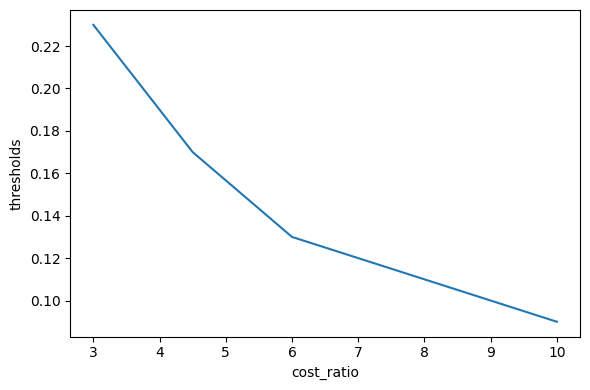

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cost_ratios, thresholds)

ax.set_xlabel("cost_ratio")
ax.set_ylabel('thresholds')
plt.tight_layout()
plt.show()

In [17]:
for ratio, t in zip(cost_ratios, thresholds):
    preds = (val_proba >= t).astype(int)
    fn = ((preds == 0) & (y_val == 1)).sum()
    fp = ((preds == 1) & (y_val == 0)).sum()
    rejection_rate = preds.mean()
    recall = ((preds == 1) & (y_val == 1)).sum() / y_val.sum()
    print(f"Cost ratio {ratio}: t={t:.2f}, reject {rejection_rate:.1%}, "
          f"recall {recall:.2f}, FN={fn}, FP={fp}")

Cost ratio 3: t=0.23, reject 26.4%, recall 0.48, FN=39753, FP=73695
Cost ratio 4.5: t=0.17, reject 43.6%, recall 0.68, FN=24543, FP=130404
Cost ratio 6: t=0.13, reject 59.1%, recall 0.82, FN=14231, FP=185320
Cost ratio 10: t=0.09, reject 76.9%, recall 0.93, FN=5569, FP=251341


In [22]:
with open(model_path / 'metric.json', 'r') as f:
    metrics = json.load(f)

In [23]:
metrics

{'threshold': 0.16,
 'train': {'ROC-AUC': 0.7439300157154369,
  'PR-AUC': 0.381689819454631,
  'brier_score': 0.12316741794347763,
  'precision': 0.2783728747025197,
  'recall': 0.7311166956633803,
  'confusion_matrix': [[241383, 147064], [20864, 56731]]},
 'val': {'ROC-AUC': 0.708335490425068,
  'PR-AUC': 0.34885062650079623,
  'brier_score': 0.13714288175106049,
  'precision': 0.2789071369106183,
  'recall': 0.7163796119902025,
  'confusion_matrix': [[200124, 142917], [21885, 55278]]},
 'test': {'ROC-AUC': 0.6935841329758616,
  'PR-AUC': 0.3104578352376564,
  'brier_score': 0.13049693405628204,
  'precision': 0.2591251104930686,
  'recall': 0.6604027583175361,
  'confusion_matrix': [[221458, 137456], [24722, 48076]]}}

In [30]:
assumed_threshold = metrics['threshold']
results = []
for cost_ratio in cost_ratios:
    fn_cost = 2000 * cost_ratio
    fp_cost = 2000
    
    opt_threshold = tune_threshold(y_true=y_val, y_proba=val_proba, fn_cost=fn_cost, fp_cost=fp_cost)
    opt_y_pred = (val_proba >= opt_threshold).astype(int)
    opt_fn = ((opt_y_pred == 0) & (y_val == 1)).sum()
    opt_fp = ((opt_y_pred == 1) & (y_val == 0)).sum()
    opt_cost = opt_fn * fn_cost + opt_fp * fp_cost
    
    assumed_y_pred = (val_proba >= assumed_threshold).astype(int)
    assumed_fn = ((assumed_y_pred == 0) & (y_val == 1)).sum()
    assumed_fp = ((assumed_y_pred == 1) & (y_val == 0)).sum()
    assumed_cost = assumed_fn * fn_cost + assumed_fp * fp_cost
    
    penalty = (assumed_cost - opt_cost) / opt_cost
    results.append({'ratio': cost_ratio, 'cost_opt': opt_cost, 'cost_assumed': assumed_cost, 'penalty_pct': penalty * 100})

In [31]:
results

[{'ratio': 3,
  'cost_opt': np.int64(385908000),
  'cost_assumed': np.int64(417144000),
  'penalty_pct': np.float64(8.094157156628004)},
 {'ratio': 4.5,
  'cost_opt': np.float64(481695000.0),
  'cost_assumed': np.float64(482799000.0),
  'penalty_pct': np.float64(0.22919067044499114)},
 {'ratio': 6,
  'cost_opt': np.int64(541412000),
  'cost_assumed': np.int64(548454000),
  'penalty_pct': np.float64(1.300673054900889)},
 {'ratio': 10,
  'cost_opt': np.int64(614062000),
  'cost_assumed': np.int64(723534000),
  'penalty_pct': np.float64(17.82751578830802)}]